In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install torch_geometric
!pip install librosa

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import glob
import librosa
import numpy as np
import torch
from torch_geometric.data import Data, DataLoader
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

# Update this path to where GTZAN is located in your Kaggle input
DATA_PATH = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original"
genres = os.listdir(DATA_PATH)
if '.ipynb_checkpoints' in genres: genres.remove('.ipynb_checkpoints')

label_encoder = LabelEncoder()
label_encoder.fit(genres)

def process_audio_to_graph(filepath, label, threshold=0.75):
    # 1. Resample and Load (22,050 Hz as required)
    try:
        y, sr = librosa.load(filepath, sr=22050, duration=29.9) # load ~30s
    except:
        return None # Skip corrupted files (e.g., jazz.00054.wav in GTZAN is famously broken)

    # 2. Segmentation: Split into 10 segments (approx 3 seconds each)
    segment_length = len(y) // 10
    node_features = []
    
    for i in range(10):
        segment = y[i*segment_length : (i+1)*segment_length]
        # Extract MFCCs for the segment (using 20 coefficients)
        mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=20)
        # Use the mean and variance across time as the node feature (40 dimensions)
        features = np.hstack((np.mean(mfcc, axis=1), np.var(mfcc, axis=1)))
        node_features.append(features)
        
    node_features = np.array(node_features)
    
    # 3. Graph Construction: Edges based on temporal adjacency and cosine similarity
    edge_index = []
    
    # Temporal edges (i connects to i+1)
    for i in range(9):
        edge_index.append([i, i+1])
        edge_index.append([i+1, i]) # Undirected
        
    # Similarity edges
    sim_matrix = cosine_similarity(node_features)
    for i in range(10):
        for j in range(i+2, 10): # Avoid adjacent nodes (already added)
            if sim_matrix[i, j] > threshold:
                edge_index.append([i, j])
                edge_index.append([j, i])
                
    # 4. Convert to PyTorch Geometric Data object
    x = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    y_tensor = torch.tensor([label_encoder.transform([label])[0]], dtype=torch.long)
    
    return Data(x=x, edge_index=edge_index, y=y_tensor)

# Build the dataset
dataset = []
for genre in tqdm(genres, desc="Processing Genres"):
    files = glob.glob(os.path.join(DATA_PATH, genre, "*.wav"))
    for f in files:
        graph_data = process_audio_to_graph(f, genre)
        if graph_data:
            dataset.append(graph_data)

print(f"Successfully created {len(dataset)} graph objects.")

Processing Genres:   0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_58/775677273.py:22: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(filepath, sr=22050, duration=29.9) # load ~30s
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Successfully created 999 graph objects.


In [4]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool

class MusicGraphSAGE(nn.Module):
    def __init__(self, in_channels=40, hidden_channels=64, out_channels=10):
        super(MusicGraphSAGE, self).__init__()
        # GraphSAGE layers
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        
        # Linear classifier head
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        
        # Layer 2
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        # Graph Readout (Mean Pooling)
        g = global_mean_pool(x, batch)
        
        # Classification (Logits, since we will use CrossEntropyLoss)
        out = self.lin(g)
        return out

In [5]:
import random
from torch.optim import AdamW

# Shuffle and split data (80% train, 20% test)
random.shuffle(dataset)
split_idx = int(len(dataset) * 0.8)
train_dataset = dataset[:split_idx]
test_dataset = dataset[split_idx:]

# PyTorch Geometric DataLoaders handle graph batching automatically
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MusicGraphSAGE(in_channels=40, hidden_channels=64, out_channels=10).to(device)
optimizer = AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epochs = 30
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        
    train_loss = total_loss / len(train_dataset)
    
    # Evaluation
    model.eval()
    correct = 0
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)
            correct += int((pred == data.y).sum())
    
    test_acc = correct / len(test_dataset)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, Test Acc: {test_acc:.4f}')

/tmp/ipykernel_58/740927055.py:11: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
/tmp/ipykernel_58/740927055.py:12: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


Epoch: 001, Loss: 37.7976, Test Acc: 0.2300
Epoch: 005, Loss: 2.5445, Test Acc: 0.3800
Epoch: 010, Loss: 1.8693, Test Acc: 0.4500
Epoch: 015, Loss: 1.4254, Test Acc: 0.4850
Epoch: 020, Loss: 1.2915, Test Acc: 0.4650
Epoch: 025, Loss: 1.2281, Test Acc: 0.5700
Epoch: 030, Loss: 1.1438, Test Acc: 0.5800


In [6]:
import os

# Create a directory for the processed graphs
os.makedirs("processed_graphs", exist_ok=True)

# Save the first 25 graphs just to be safe
for i in range(25):
    torch.save(dataset[i], f"processed_graphs/graph_sample_{i:03d}.pt")
    
print("Successfully saved 25 graph samples as .pt files!")

Successfully saved 25 graph samples as .pt files!


In [9]:
import librosa
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

class MelSpecDataset(Dataset):
    def __init__(self, filepaths, labels, label_encoder, max_pad_len=1292):
        self.filepaths = filepaths
        self.labels = labels
        self.label_encoder = label_encoder
        self.max_pad_len = max_pad_len

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        filepath = self.filepaths[idx]
        label = self.labels[idx]
        
        # Load audio
        y, sr = librosa.load(filepath, sr=22050, duration=29.9)
        
        # Extract Log-Mel Spectrogram (128 bins as required)
        melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        log_melspec = librosa.power_to_db(melspec, ref=np.max)
        
        # Pad or truncate to ensure uniform image sizes for the CNN
        if log_melspec.shape[1] > self.max_pad_len:
            log_melspec = log_melspec[:, :self.max_pad_len]
        else:
            pad_width = self.max_pad_len - log_melspec.shape[1]
            log_melspec = np.pad(log_melspec, pad_width=((0, 0), (0, pad_width)), mode='constant')
            
        # Add channel dimension for CNN: (1, H, W)
        img_tensor = torch.tensor(log_melspec, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(self.label_encoder.transform([label])[0], dtype=torch.long)
        
        return img_tensor, label_tensor

# Extract filepaths and labels from the previous step's successful loads
filepaths = []
labels = []
for genre in genres:
    files = glob.glob(os.path.join(DATA_PATH, genre, "*.wav"))
    for f in files:
        if f != "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original/jazz/jazz.00054.wav": # Skip known broken file
            filepaths.append(f)
            labels.append(genre)

# Split data (80% train, 20% test) matching the GNN split
c_dataset = list(zip(filepaths, labels))
random.shuffle(c_dataset)
split_idx = int(len(c_dataset) * 0.8)

train_c_data = c_dataset[:split_idx]
test_c_data = c_dataset[split_idx:]

train_melspec = MelSpecDataset([x[0] for x in train_c_data], [x[1] for x in train_c_data], label_encoder)
test_melspec = MelSpecDataset([x[0] for x in test_c_data], [x[1] for x in test_c_data], label_encoder)

train_loader_cnn = DataLoader(train_melspec, batch_size=32, shuffle=True)
test_loader_cnn = DataLoader(test_melspec, batch_size=32, shuffle=False)

In [10]:
import torch.nn.functional as F

class SpectrogramCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SpectrogramCNN, self).__init__()
        # Input shape: (Batch, 1, 128, 1292)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # After 3 max pools of 2x2, spatial dimensions reduce by a factor of 8
        # 128 / 8 = 16, 1292 / 8 = 161
        self.fc1 = nn.Linear(64 * 16 * 161, 128) 
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Flatten for the fully connected layers
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [11]:
cnn_model = SpectrogramCNN(num_classes=10).to(device)
cnn_optimizer = AdamW(cnn_model.parameters(), lr=0.001)
cnn_criterion = nn.CrossEntropyLoss()

epochs = 15 # CNNs usually converge faster on this dataset

print("--- Starting CNN Baseline Training ---")
for epoch in range(1, epochs + 1):
    cnn_model.train()
    total_loss = 0
    
    for imgs, lbls in train_loader_cnn:
        imgs, lbls = imgs.to(device), lbls.to(device)
        
        cnn_optimizer.zero_grad()
        outputs = cnn_model(imgs)
        loss = cnn_criterion(outputs, lbls)
        
        loss.backward()
        cnn_optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        
    train_loss = total_loss / len(train_melspec)
    
    # Evaluation
    cnn_model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, lbls in test_loader_cnn:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = cnn_model(imgs)
            preds = outputs.argmax(dim=1)
            correct += int((preds == lbls).sum())
            
    test_acc = correct / len(test_melspec)
    print(f'Epoch: {epoch:03d} | Loss: {train_loss:.4f} | Test Acc: {test_acc:.4f}')

--- Starting CNN Baseline Training ---
Epoch: 001 | Loss: 32.3257 | Test Acc: 0.1250
Epoch: 002 | Loss: 2.0600 | Test Acc: 0.2500
Epoch: 003 | Loss: 1.7729 | Test Acc: 0.3550
Epoch: 004 | Loss: 1.4779 | Test Acc: 0.4400
Epoch: 005 | Loss: 1.1403 | Test Acc: 0.4450
Epoch: 006 | Loss: 0.9038 | Test Acc: 0.4450
Epoch: 007 | Loss: 0.5062 | Test Acc: 0.4950
Epoch: 008 | Loss: 0.3778 | Test Acc: 0.4400
Epoch: 009 | Loss: 0.2738 | Test Acc: 0.4600
Epoch: 010 | Loss: 0.1511 | Test Acc: 0.5350
Epoch: 011 | Loss: 0.1300 | Test Acc: 0.5300
Epoch: 012 | Loss: 0.1159 | Test Acc: 0.5050
Epoch: 013 | Loss: 0.1051 | Test Acc: 0.4550
Epoch: 014 | Loss: 0.0873 | Test Acc: 0.5250
Epoch: 015 | Loss: 0.1070 | Test Acc: 0.5150


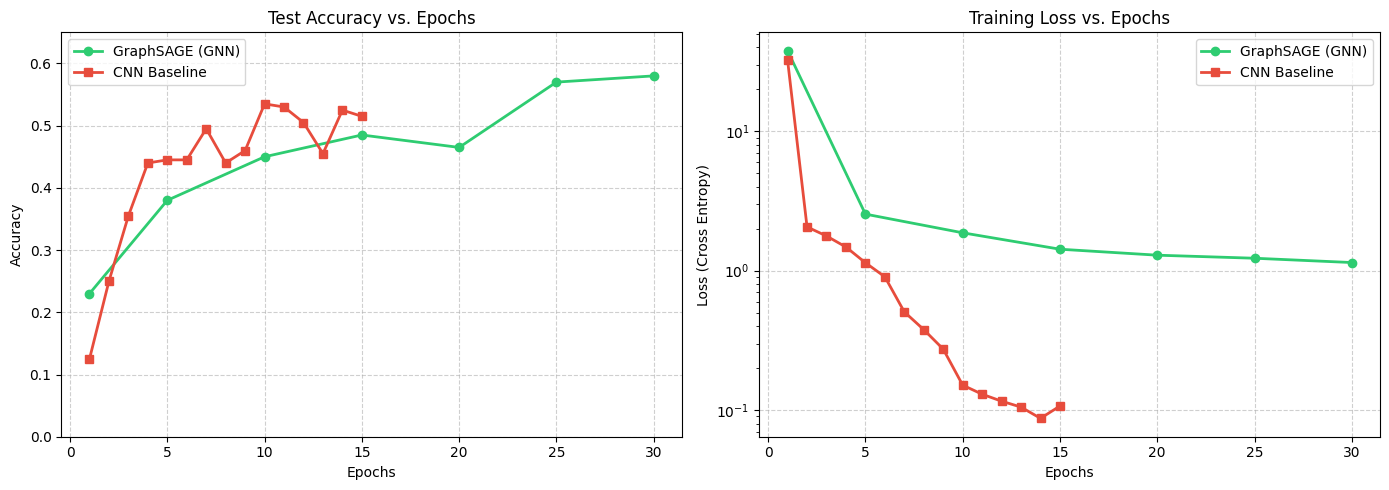

In [13]:
import matplotlib.pyplot as plt

# Data from your GNN training logs
gnn_epochs = [1, 5, 10, 15, 20, 25, 30]
gnn_loss = [37.7976, 2.5445, 1.8693, 1.4254, 1.2915, 1.2281, 1.1438]
gnn_acc = [0.2300, 0.3800, 0.4500, 0.4850, 0.4650, 0.5700, 0.5800]

# Data from your CNN training logs
cnn_epochs = list(range(1, 16))
cnn_loss = [32.3257, 2.0600, 1.7729, 1.4779, 1.1403, 0.9038, 0.5062, 0.3778, 0.2738, 
            0.1511, 0.1300, 0.1159, 0.1051, 0.0873, 0.1070]
cnn_acc = [0.1250, 0.2500, 0.3550, 0.4400, 0.4450, 0.4450, 0.4950, 0.4400, 0.4600, 
           0.5350, 0.5300, 0.5050, 0.4550, 0.5250, 0.5150]

# Create a figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test Accuracy
ax1.plot(gnn_epochs, gnn_acc, label='GraphSAGE (GNN)', marker='o', color='#2ecc71', linewidth=2)
ax1.plot(cnn_epochs, cnn_acc, label='CNN Baseline', marker='s', color='#e74c3c', linewidth=2)
ax1.set_title('Test Accuracy vs. Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 0.65)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Plot 2: Training Loss
ax2.plot(gnn_epochs, gnn_loss, label='GraphSAGE (GNN)', marker='o', color='#2ecc71', linewidth=2)
ax2.plot(cnn_epochs, cnn_loss, label='CNN Baseline', marker='s', color='#e74c3c', linewidth=2)
ax2.set_title('Training Loss vs. Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss (Cross Entropy)')
ax2.set_yscale('log') # Log scale because initial loss is very high
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()